# Lab 1 实验报告

---
## 一、实验概述

本实验围绕数字图像处理中四类基础问题展开：灰度图生成、灰度级量化、图像缩放以及基于阈值的彩色叠加。相比单纯完成代码，本报告更关注两个核心问题：  
1. 每个实验现象背后的图像处理原理是什么；  
2. 从实验结果中能够得出怎样的规律与结论。

四个任务分别对应图像处理中的四个基础概念：  
- **表示**：图像如何用矩阵表达；  
- **量化**：有限灰度级如何影响视觉质量；  
- **采样/重建**：分辨率变化如何造成信息损失；  
- **可视化**：如何通过颜色叠加突出目标区域。  

因此，本实验的价值不仅在于“做出图”，更在于借助实验结果理解数字图像处理中的基本机制。


In [1]:
# 环境检查（可选）
%pip list


Package                  Version
------------------------ -----------
anaconda-anon-usage      0.5.0
annotated-types          0.6.0
appnope                  0.1.4
archspec                 0.2.3
asttokens                3.0.0
boltons                  24.1.0
Brotli                   1.0.9
certifi                  2025.1.31
cffi                     1.17.1
charset-normalizer       3.3.2
cmocean                  4.0.3
comm                     0.2.2
conda                    25.3.1
conda-anaconda-telemetry 0.1.2
conda-anaconda-tos       0.1.2
conda-content-trust      0.2.0
conda-libmamba-solver    25.1.1
conda-package-handling   2.4.0
conda_package_streaming  0.11.0
contourpy                1.3.1
cryptography             43.0.3
cycler                   0.12.1
debugpy                  1.8.11
decorator                5.2.1
distro                   1.9.0
exceptiongroup           1.2.2
executing                2.1.0
fonttools                4.56.0
frozendict               2.4.2
idna              

## 二、Task 1：灰度图生成与 Mach band effect 观察

### 1. 原理分析
数字灰度图像本质上是一个二维矩阵，矩阵中每个元素对应一个像素的灰度值。  
当灰度值从左到右均匀增加时，可以形成连续灰度渐变图；当灰度值只在若干固定宽度的区域内保持常数，并在边界处突变时，则形成分段灰度带图。

这一实验的重点不只是“生成图像”，而是观察 **马赫带效应**。在人眼视觉系统中，亮度发生突变的边界区域往往会被主观增强，因此即使图像中只是简单的灰度分段，人眼仍会在边界附近感受到额外的亮带或暗带。  
这说明视觉感知并不是对像素值的机械复制，而是带有明显的边缘敏感性。换言之，人眼对“变化”比对“绝对值”更敏感。

### 2. 结果分析
连续灰度图的视觉效果表现为平滑过渡，灰度变化连续，没有明显边界，因此整体观感自然、均匀。  
而分段灰度图虽然每个灰度带内部数值恒定，但在相邻灰度带的交界处，会明显感觉到边界附近出现额外的亮暗增强现象。这个现象并不是程序额外生成了新的灰度值，而是视觉系统对灰度跳变的响应结果。

从实验结果可以得到两点认识：  
- 第一，图像的显示效果不仅取决于像素值本身，还取决于视觉系统如何解释这些像素；  
- 第二，边界和突变在图像感知中具有更高的重要性，这也是后续边缘检测、锐化增强等方法成立的重要基础。

### 3. 小结
Task 1 说明了灰度图像可以通过矩阵直接构造，同时也通过 Mach band effect 验证了视觉系统对边界的强化响应。这一实验为理解“图像数值”和“图像感知”之间的差异提供了非常直观的例子。


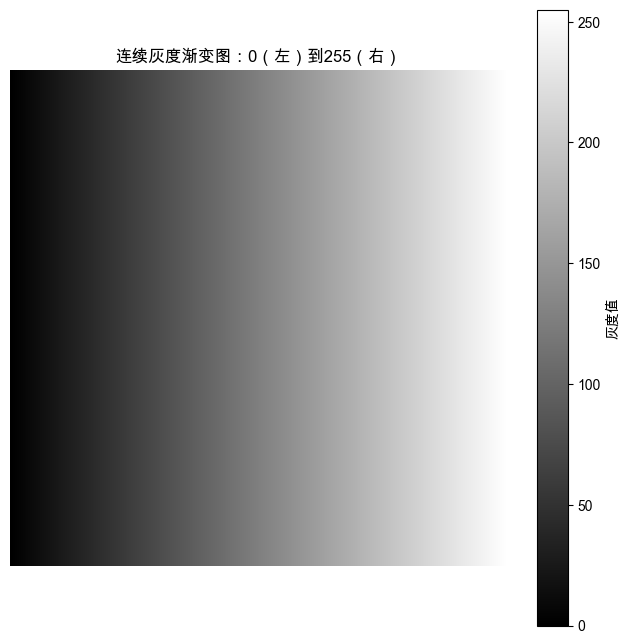

连续灰度图尺寸: (256, 256)
最小灰度值: 0, 最大灰度值: 255


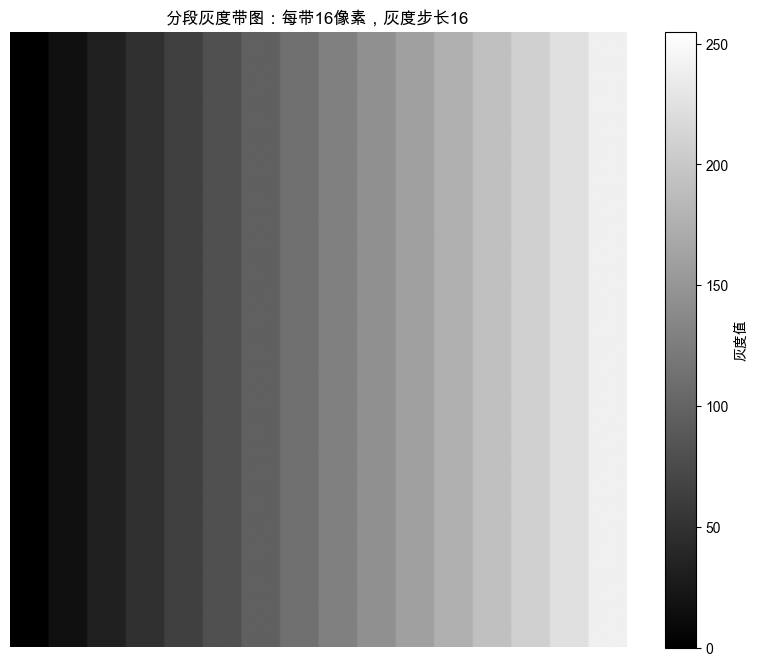

分段灰度图尺寸: (256, 256)
灰度带取值: [  0  16  32  48  64  80  96 112 128 144 160 176 192 208 224 240]


In [1]:
# Task 1：灰度图生成与 Mach band effect 观察
import numpy as np
import matplotlib.pyplot as plt

# 中文字体设置（适配 macOS）
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ----------------------------
# Part A：连续灰度渐变图
# ----------------------------
image = np.tile(np.arange(256, dtype=np.uint8), (256, 1))

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('连续灰度渐变图：0（左）到255（右）')
plt.colorbar(label='灰度值')
plt.axis('off')
plt.show()

print(f'连续灰度图尺寸: {image.shape}')
print(f'最小灰度值: {image.min()}, 最大灰度值: {image.max()}')

# ----------------------------
# Part B：分段灰度带图（每带16像素，步长16）
# ----------------------------
image_bands = np.zeros((256, 256), dtype=np.uint8)
for i in range(16):
    gray_value = i * 16
    image_bands[:, i * 16:(i + 1) * 16] = gray_value

plt.figure(figsize=(10, 8))
plt.imshow(image_bands, cmap='gray', vmin=0, vmax=255)
plt.title('分段灰度带图：每带16像素，灰度步长16')
plt.colorbar(label='灰度值')
plt.axis('off')
plt.show()

print(f'分段灰度图尺寸: {image_bands.shape}')
print(f'灰度带取值: {np.unique(image_bands)}')


## 三、Task 2：灰度级量化

### 1. 原理分析
灰度图像通常使用有限位数表示。对于标准 8 bit 灰度图，每个像素可取 0 到 255，共 256 个灰度级。  
所谓灰度量化，就是把原来较丰富的灰度取值压缩到更少的离散等级。例如量化为 $2^n$ 个灰度级时，多个相邻的原始灰度值会被映射到同一个输出值。

量化的本质是“用更少的状态表示原有信息”。这样做虽然可以降低表示复杂度，但代价是灰度层次减少，图像中原本平滑的过渡区域会被离散化，严重时会产生明显的分层感，也就是常说的假轮廓现象。  
因此，量化问题本质上体现的是**图像质量与数据简化之间的折中**。

### 2. 结果分析
从不同 n 值下的实验结果可以看出，当 n 很小时，图像只剩下很少的灰度级，原本连续的过渡区域被切分成若干明显的灰度层，图像显得生硬，细节和纹理信息损失较大。  
随着 n 的增大，灰度级数量逐步增加，图像层次逐渐变丰富，视觉效果也越来越接近原始图像。

这说明灰度级数量直接决定了图像的灰度表达能力：  
- 灰度级过少时，图像难以表现平滑变化，容易出现块状感和断层感；  
- 灰度级足够多时，图像的亮暗过渡更自然，细节保留更完整。  

从图像处理角度看，这一实验反映出量化误差会改变图像的视觉连续性，而这种误差在灰度变化缓慢的区域尤其明显。

### 3. 小结
Task 2 说明，量化虽然可以降低图像表示复杂度，但会牺牲图像层次与细节。量化级数越低，失真越明显；量化级数越高，图像越接近原始效果。这一结论对于理解位深、图像压缩与显示质量之间的关系非常重要。


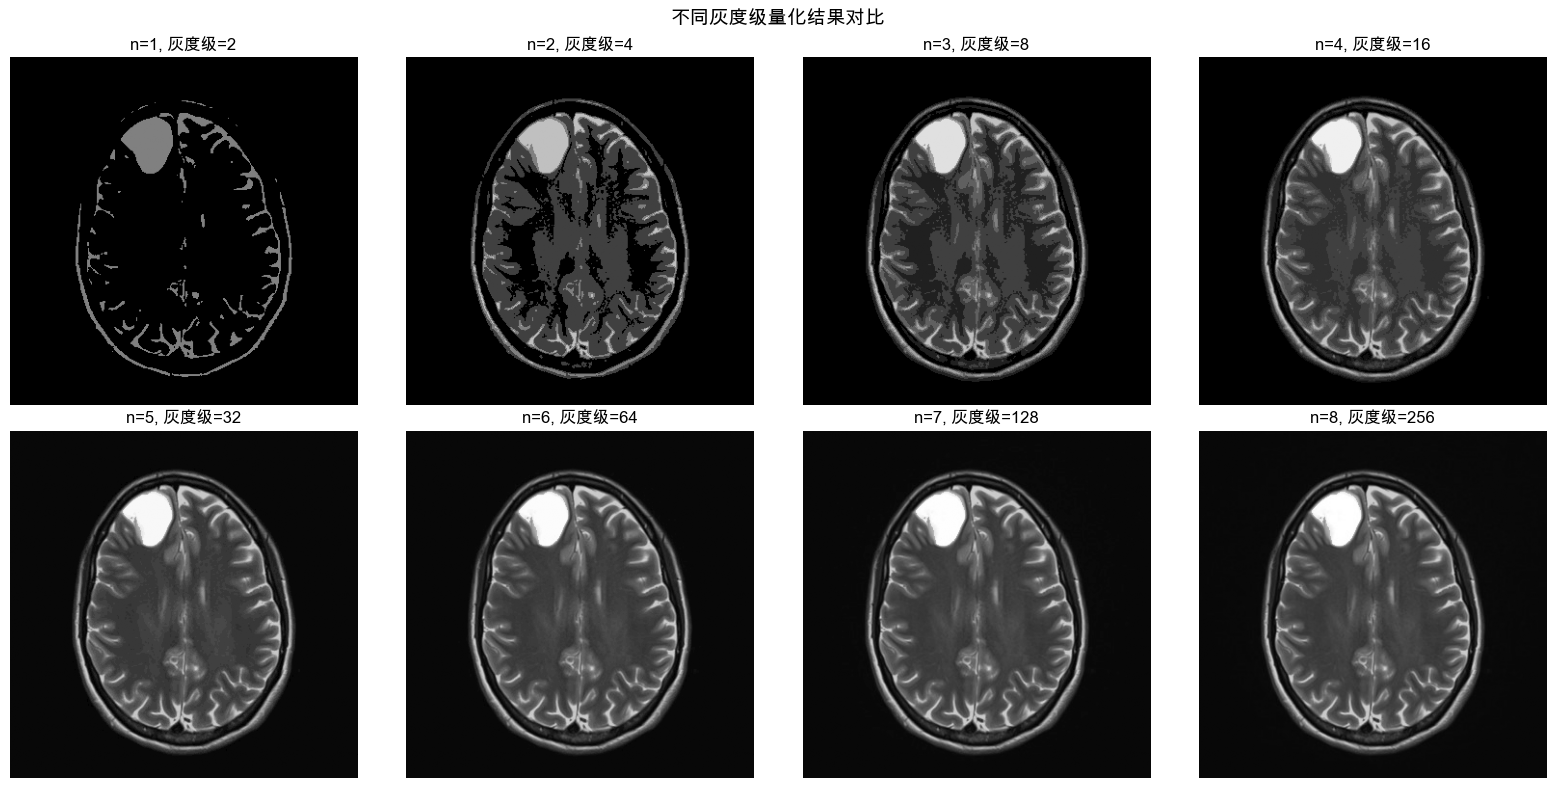

In [1]:
# Task 2：灰度级量化
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取实验图像
x = np.load('lab1.npy')

def reduce_gray_levels(x, n):
    '''
    将图像量化到 2^n 个灰度级
    参数:
        x: 输入灰度图像
        n: 输出灰度级满足 2^n
    返回:
        量化后的图像
    '''
    levels = 2 ** n
    step = 256 / levels
    y = np.floor(x / step) * step
    return y.astype(np.uint8)

ns = [1, 2, 3, 4, 5, 6, 7, 8]

plt.figure(figsize=(16, 8))
for i, n in enumerate(ns):
    y = reduce_gray_levels(x, n)
    plt.subplot(2, 4, i + 1)
    plt.imshow(y, cmap='gray', vmin=0, vmax=255)
    plt.title(f'n={n}, 灰度级={2**n}')
    plt.axis('off')

plt.suptitle('不同灰度级量化结果对比', fontsize=14)
plt.tight_layout()
plt.show()


## 四、Task 3：图像缩小、放大与细节比较

### 1. 原理分析
图像缩小本质上对应空间采样密度的降低，也就是降采样过程。  
当采样间隔增大时，部分原始像素不会被保留下来，因此图像中的细节信息，尤其是高频信息，会在这一过程中被削弱甚至直接丢失。随后即使再把图像放大回原尺寸，恢复的也只是“尺寸”，而不是“原始信息”。

本实验采用较直观的最近邻方式进行缩小和放大。最近邻方法实现简单，但其本质是保留少量采样点并通过重复像素扩展图像，因此无法真正重建被舍弃的细节。这也是为什么放大后的图像往往会出现块状感、边缘不平滑和细节模糊。

### 2. 结果分析
从实验结果可以看出，缩小倍数较小时，恢复后的图像仍能保留原图的大体结构，但局部细节已经开始变粗糙；当缩小倍数进一步增大时，恢复图像的模糊感和块状感会更加明显。  
这说明在降采样过程中，采样点越稀疏，丢失的信息越多，而这些丢失的信息在简单放大后无法重新获得。

结合灰度剖面曲线来看，原图在细节丰富的位置往往存在较快的灰度变化，而恢复图像的曲线会变得更平缓或呈现明显的阶梯状。这意味着：  
- 高频细节被削弱；  
- 局部突变被平均化或离散化；  
- 恢复图像只能近似保留低频轮廓，而难以精确重建精细结构。  

这一现象揭示了图像缩放中的一个关键事实：**尺寸恢复不等于信息恢复**。图像一旦在采样阶段丢失信息，后续简单插值或像素复制通常无法无损找回这些细节。

### 3. 小结
Task 3 清楚展示了采样率变化对图像质量的影响。缩小会造成不可逆的信息丢失，而简单放大只能恢复外形尺寸，无法恢复已经丢失的高频内容。该实验帮助理解了分辨率、采样与重建误差之间的本质联系。


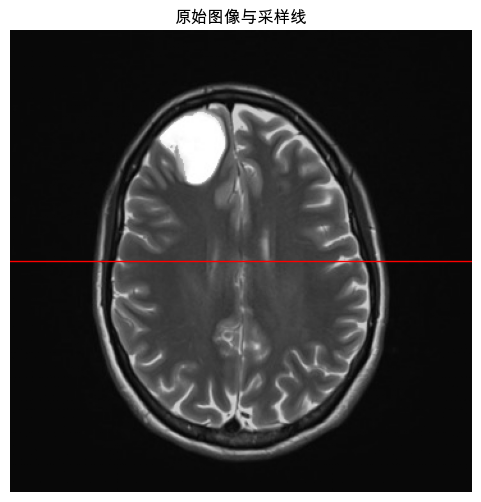

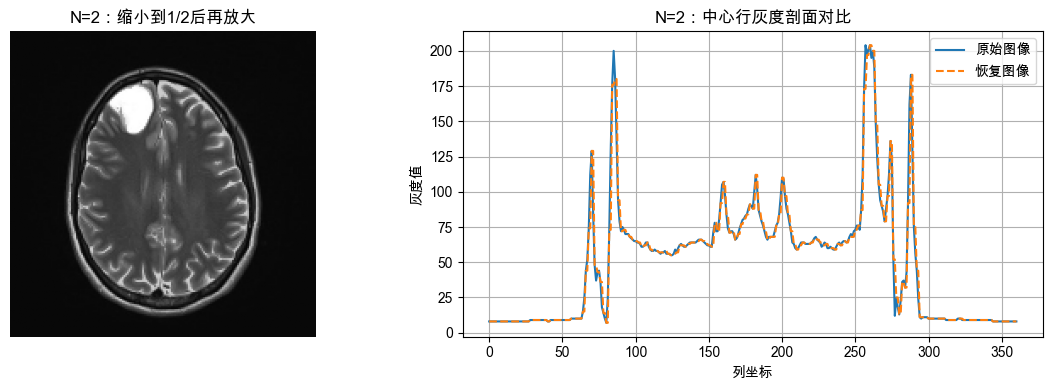

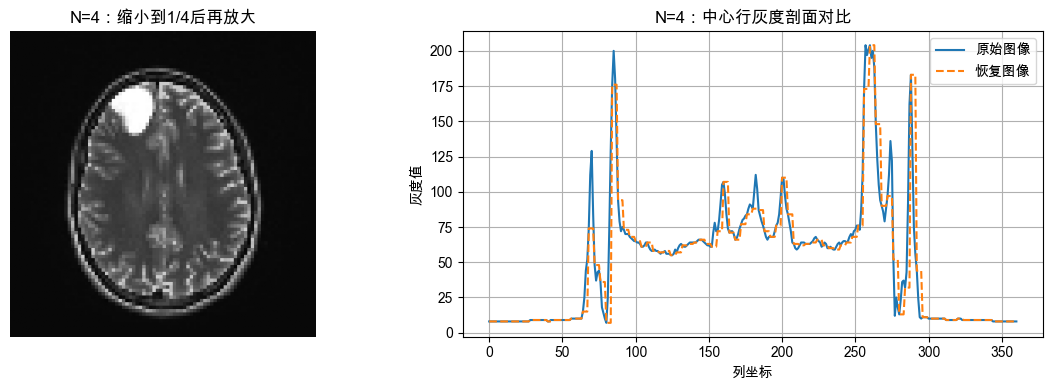

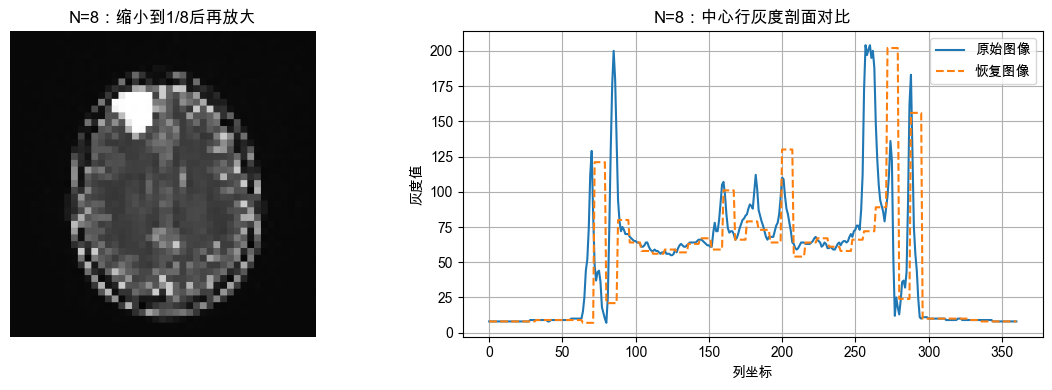

In [2]:
# Task 3：图像缩小、放大与细节比较
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 若前一个单元已读入 x，这里可直接使用；否则取消下一行注释
# x = np.load('lab1.npy')

row = x.shape[0] // 2
original_line = x[row, :]
Ns = [2, 4, 8]

plt.figure(figsize=(6, 6))
plt.imshow(x, cmap='gray', vmin=0, vmax=255)
plt.axhline(row, color='r', linewidth=1)
plt.title('原始图像与采样线')
plt.axis('off')
plt.show()

for N in Ns:
    # 最近邻方式缩小
    small = x[::N, ::N]

    # 再放大回近似原尺寸
    small_up = np.repeat(np.repeat(small, N, axis=0), N, axis=1)
    small_up = small_up[:x.shape[0], :x.shape[1]]

    restored_line = small_up[row, :]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(small_up, cmap='gray', vmin=0, vmax=255)
    plt.title(f'N={N}：缩小到1/{N}后再放大')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.plot(original_line, label='原始图像')
    plt.plot(restored_line, label='恢复图像', linestyle='--')
    plt.title(f'N={N}：中心行灰度剖面对比')
    plt.xlabel('列坐标')
    plt.ylabel('灰度值')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 五、Task 4：颜色叠加

### 1. 原理分析
灰度图像只有一个通道，每个像素仅表示亮度信息。如果希望把某些满足条件的区域从背景中直观区分出来，可以先依据阈值生成二值掩膜，再将该掩膜叠加到彩色图像通道中。  
本实验中采用的规则是：当灰度值满足 $I > threshold$ 时，将该像素视为目标区域；否则视为背景区域。

随后，将原灰度图复制到 RGB 三个通道中，再对满足条件的区域修改通道值，例如把红色通道设置为高值、其余通道压低，就能使目标区域以红色方式被高亮显示。  
从本质上讲，这一过程包含两个步骤：  
- **阈值分割**：根据灰度条件把目标区域提取出来；  
- **彩色可视化**：通过通道重映射，使目标区域在视觉上更加突出。  

这种方法在医学图像分割结果展示、目标检测后处理以及显微图像标注中都非常常见，因为它兼顾了原图背景信息与目标强调效果。

### 2. 结果分析
实验结果显示，在给定阈值下，高于阈值的区域被顺利提取出来，并以红色覆盖到原灰度背景上。这样一来，观察者既能够看到原图整体结构，又能够快速识别目标区域的位置和范围。  
相比单独显示二值掩膜，颜色叠加的方式更具有解释性，因为它不会完全丢弃背景信息，而是把目标与背景整合到同一幅图中。

同时，这一实验也反映出阈值选择的重要性：  
- 当阈值偏低时，会有更多区域被纳入目标，可能产生过分高亮的现象；  
- 当阈值偏高时，真正重要的区域可能被漏掉。  

因此，颜色叠加的显示质量实际上依赖于前一步阈值分割的质量。显示只是最后一步，可视化效果的好坏仍然由分割结果决定。

### 3. 小结
Task 4 说明了如何利用“阈值掩膜 + RGB 通道操作”实现目标区域的高亮显示。这不仅是一种直观有效的结果展示方法，也体现了图像处理中“分割”和“可视化”两个环节之间的紧密联系。


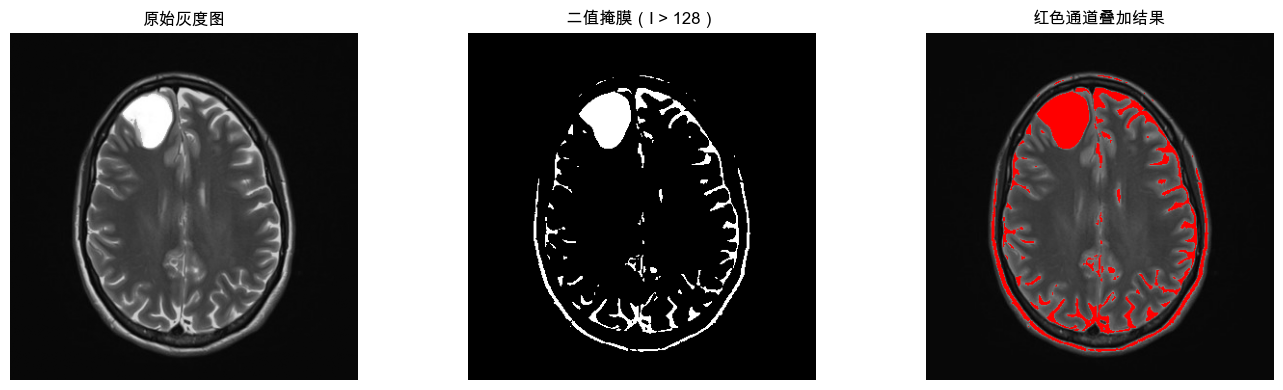

In [3]:
# Task 4：颜色叠加（Color Overlay）
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 若前一个单元已读入 x，这里可直接使用；否则取消下一行注释
# x = np.load('lab1.npy')

threshold = 128
mask = (x > threshold).astype(np.uint8)

color_img = np.stack([x, x, x], axis=-1).astype(np.uint8)

# 将 mask 区域标为红色
color_img[..., 0][mask == 1] = 255
color_img[..., 1][mask == 1] = 0
color_img[..., 2][mask == 1] = 0

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(x, cmap='gray', vmin=0, vmax=255)
plt.title('原始灰度图')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title(f'二值掩膜（I > {threshold}）')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(color_img)
plt.title('红色通道叠加结果')
plt.axis('off')

plt.tight_layout()
plt.show()


## 六、总体总结

本实验虽然操作相对基础，但所对应的原理都非常核心。四个任务分别从不同角度揭示了数字图像处理中的基本规律：

- **Task 1** 说明图像可以看作矩阵，并展示了视觉系统对灰度边界的主观增强现象；  
- **Task 2** 说明量化会在降低表示复杂度的同时带来灰度层次损失；  
- **Task 3** 说明降采样会引起不可逆的信息缺失，而放大不能真正恢复原始细节；  
- **Task 4** 说明通过阈值分割与颜色叠加可以有效突出感兴趣区域。  

综合来看，本实验最重要的收获不是单独掌握几个代码操作，而是理解以下几点：  
1. 图像处理中的很多问题都可以归结为对矩阵数据的变换；  
2. 图像的显示质量由采样、量化和可视化策略共同决定；  
3. 人眼观察到的结果并不总是像素值的直接反映，而是数值与视觉机制共同作用的结果。  

这些认识为后续学习图像增强、边缘检测、图像分割以及医学图像分析提供了理论基础。
